# Day-Ahead 24-Hour Forecasting at 15-Minute Granularity (LightGBM + skforecast Direct)

This notebook mirrors the TFT preprocessing and metrics, but uses a direct multi-step LightGBM forecaster (`ForecasterDirect`) so each horizon is predicted by its own model and recursive error accumulation is avoided.

## 1) Install dependencies (only if needed)
Run once if imports fail, then restart kernel.

In [7]:
%pip install -q lightgbm skforecast holidays

Note: you may need to restart the kernel to use updated packages.


In [8]:
import warnings
from pathlib import Path

import holidays
import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from skforecast.direct import ForecasterDirect
from skforecast.preprocessing import RollingFeatures
from skforecast.recursive import ForecasterRecursive

warnings.filterwarnings("ignore")
np.random.seed(42)

In [9]:
# Paths + full preprocessing (aligned with TFT notebook)
def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src").exists():
            return parent
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "Data" if (PROJECT_ROOT / "Data").exists() else PROJECT_ROOT / "data"
PREDICTION_DIR = PROJECT_ROOT / "Prediction"

PRICE_PATH = DATA_DIR / "price_data_rotated_2d.csv"
WEATHER_PATH = DATA_DIR / "historical_hourly_2023_2025.csv"
WEATHER_DAILY = DATA_DIR / "historical_daily_2023_2025.csv"
OUTPUT_PATH = PREDICTION_DIR / "lgbm_skforecast_direct_day_ahead_24h_15min.csv"

price_df = pd.read_csv(PRICE_PATH)
ts_col = "timestamp" if "timestamp" in price_df.columns else "Timestamp"
price_df[ts_col] = pd.to_datetime(price_df[ts_col], utc=True, errors="coerce").dt.tz_convert(None)
price_df = price_df.rename(columns={ts_col: "Timestamp"})
price_df = price_df.sort_values("Timestamp").drop_duplicates("Timestamp")

base_cols = [
    c
    for c in [
        "Timestamp",
        "price",
        "demand_itsdo",
        "demand_indo",
        "demand_inddem",
        "demand_forecast",
        "wind_generation",
        "solar_generation",
        "margin_daily_forecast",
    ]
    if c in price_df.columns
]
price_df = price_df[base_cols]

full_index = pd.date_range(price_df["Timestamp"].min(), price_df["Timestamp"].max(), freq="15min")
price_df = price_df.set_index("Timestamp").reindex(full_index).rename_axis("Timestamp").reset_index()

weather_df = pd.read_csv(WEATHER_PATH)
w_ts = "Timestamp" if "Timestamp" in weather_df.columns else "timestamp_utc"
weather_df[w_ts] = pd.to_datetime(weather_df[w_ts], utc=True, errors="coerce").dt.tz_convert(None)
weather_df = weather_df.rename(columns={w_ts: "WeatherTimestamp"}).sort_values("WeatherTimestamp")

hourly_keep = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "precipitation",
    "rain",
    "snowfall",
    "cloud_cover",
    "cloud_cover_low",
    "cloud_cover_mid",
    "cloud_cover_high",
    "shortwave_radiation",
    "direct_radiation",
    "wind_speed_10m",
    "wind_gusts_10m",
    "wind_direction_10m",
    "surface_pressure",
    "weather_code",
]
hourly_keep = [c for c in hourly_keep if c in weather_df.columns]
weather_df = weather_df[["WeatherTimestamp"] + hourly_keep]

weather_df = weather_df.set_index("WeatherTimestamp")
weather_15min_index = pd.date_range(price_df["Timestamp"].min(), price_df["Timestamp"].max(), freq="15min")
weather_15min = weather_df.reindex(weather_15min_index)

numeric_weather_cols = [c for c in weather_15min.columns if c != "weather_code"]
if numeric_weather_cols:
    weather_15min[numeric_weather_cols] = weather_15min[numeric_weather_cols].interpolate(method="time", limit_direction="both")
if "weather_code" in weather_15min.columns:
    weather_15min["weather_code"] = weather_15min["weather_code"].ffill().bfill()

weather_15min = weather_15min.reset_index().rename(columns={"index": "Timestamp"})
df = price_df.merge(weather_15min, on="Timestamp", how="left")

daily_df = pd.read_csv(WEATHER_DAILY)
d_ts = "date_utc" if "date_utc" in daily_df.columns else "Timestamp"
daily_df[d_ts] = pd.to_datetime(daily_df[d_ts], utc=True, errors="coerce").dt.tz_convert(None)
daily_df = daily_df.rename(columns={d_ts: "Timestamp"}).sort_values("Timestamp")

if {"sunrise", "daylight_duration"}.issubset(daily_df.columns):
    sunrise = pd.to_datetime(daily_df["sunrise"], errors="coerce").dt.tz_localize(None)
    day_length_hours = daily_df["daylight_duration"] / 3600.0
    safe_day_length = day_length_hours.replace(0, np.nan)
    solar_noon_dt = sunrise + pd.to_timedelta(day_length_hours / 2, unit="h")
    hours = (daily_df["Timestamp"] - solar_noon_dt) / np.timedelta64(1, "h")
    daily_df["Solar_intensity"] = np.maximum(0, np.cos(hours * np.pi / safe_day_length)).fillna(0.0)

excluded_daily_cols = {"Timestamp", "sunrise", "sunset", "daylight_duration", "sunshine_duration"}
daily_numeric = [
    c
    for c in daily_df.columns
    if c not in excluded_daily_cols and pd.api.types.is_numeric_dtype(daily_df[c])
]
daily_features = daily_df[["Timestamp"] + daily_numeric].drop_duplicates("Timestamp")
daily_features = daily_features.set_index("Timestamp")
daily_15min = daily_features.reindex(weather_15min_index).ffill().bfill().reset_index().rename(columns={"index": "Timestamp"})
df = df.merge(daily_15min, on="Timestamp", how="left")

for col in df.columns:
    if col == "Timestamp":
        continue
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].interpolate(limit_direction="both").ffill().bfill()

#df = df[df["Timestamp"] > "2025-01-01"]
df = df.dropna(subset=["Timestamp", "price"]).sort_values("Timestamp").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Range: {df['Timestamp'].min()} -> {df['Timestamp'].max()}")
display(df.head(3))

Rows: 104,832
Range: 2023-03-03 15:00:00 -> 2026-02-27 14:45:00


,Timestamp,price,demand_itsdo,demand_indo,demand_inddem,demand_forecast,wind_generation,solar_generation,margin_daily_forecast,temperature_2m,...,weather_code_x,weather_code_y,shortwave_radiation_sum,precipitation_sum,rain_sum,snowfall_sum,precipitation_hours,temperature_2m_max,temperature_2m_min,Solar_intensity
0,2023-03-03 15:00:00,153.41,37100.0,35508.0,-12224.0,35185.0,3324.766,1276.0,5154.0,5.8000,...,3.0,3.0,8.56,0.0,0.0,0.0,0.0,5.0,-1.55,0.0
1,2023-03-03 15:15:00,153.41,37100.0,35508.0,-12224.0,35185.0,3324.766,1276.0,5154.0,5.7375,...,3.0,3.0,8.56,0.0,0.0,0.0,0.0,5.0,-1.55,0.0
2,2023-03-03 15:30:00,148.96,37699.0,36104.0,-1702.0,36394.0,3598.338,974.0,5154.0,5.6750,...,3.0,3.0,8.56,0.0,0.0,0.0,0.0,5.0,-1.55,0.0


In [10]:
price_mean = df["price"].mean()
price_std = df["price"].std()
print(f"Price mean: {price_mean:.2f}, std: {price_std:.2f}")

Price mean: 79.02, std: 35.68


In [11]:
# Patch extreme prices across full history using time-slot medians from in-range values.
if "price" not in df.columns:
    raise KeyError("Expected 'price' column in df")

if "price_raw" not in df.columns:
    df["price_raw"] = df["price"]
if "is_price_patched" not in df.columns:
    df["is_price_patched"] = 0

PRICE_CAP_HIGH = price_mean + 2*price_std
PRICE_CAP_LOW = price_mean - 2*price_std
bad_mask = (df["price"] > PRICE_CAP_HIGH) | (df["price"] < PRICE_CAP_LOW)
good_mask = ~bad_mask

# Build replacement values from in-range prices at same time-of-day.
slot_median = df.loc[good_mask].groupby(df.loc[good_mask, "Timestamp"].dt.time)["price"].median()
replacement_values = df.loc[bad_mask, "Timestamp"].dt.time.map(slot_median)
fallback_median = float(df.loc[good_mask, "price"].median()) if good_mask.any() else float(df["price"].median())
replacement_values = replacement_values.fillna(fallback_median)

df.loc[bad_mask, "price"] = replacement_values.values
df.loc[bad_mask, "is_price_patched"] = 1

patched_rows = int(bad_mask.sum())
patched_pct = (patched_rows / len(df) * 100.0) if len(df) else 0.0
print(
    f"Patched rows (< {PRICE_CAP_LOW:.0f} or > {PRICE_CAP_HIGH:.0f}): "
    f"{patched_rows} ({patched_pct:.2f}%)"
)

Patched rows (< 8 or > 150): 5940 (5.67%)


In [12]:
# Feature engineering + split setup (aligned with TFT variables)
uk_holidays = holidays.CountryHoliday("UK")
df["hour"] = df["Timestamp"].dt.hour.astype(int)
df["quarter_hour"] = (df["Timestamp"].dt.minute // 15).astype(int)
df["quarter_of_day"] = ((df["Timestamp"].dt.hour * 60 + df["Timestamp"].dt.minute) // 15).astype(int)
df["day_of_week"] = df["Timestamp"].dt.dayofweek.astype(int)
df["is_weekend"] = (df["Timestamp"].dt.dayofweek >= 5).astype(int)
df["is_holiday"] = df["Timestamp"].dt.date.isin(uk_holidays).astype(int)
df["is_working_day"] = ((df["is_weekend"] == 0) & (df["is_holiday"] == 0)).astype(int)

minute_of_day = df["Timestamp"].dt.hour * 60 + df["Timestamp"].dt.minute
df["tod_sin"] = np.sin(2 * np.pi * minute_of_day / 1440.0)
df["tod_cos"] = np.cos(2 * np.pi * minute_of_day / 1440.0)
df["dow_sin"] = np.sin(2 * np.pi * df["Timestamp"].dt.dayofweek / 7.0)
df["dow_cos"] = np.cos(2 * np.pi * df["Timestamp"].dt.dayofweek / 7.0)




df["time_idx"] = np.arange(len(df), dtype=np.int64)

HORIZON = 96
VAL_STEPS = 21 * 24 * 4
TEST_STEPS = 21 * 24 * 4

known_weather = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "precipitation",
    "rain",
    "snowfall",
    "cloud_cover",
    "cloud_cover_low",
    "cloud_cover_mid",
    "cloud_cover_high",
    "shortwave_radiation",
    "direct_radiation",
    "wind_speed_10m",
    "wind_gusts_10m",
    "wind_direction_10m",
    "surface_pressure",
    "Solar_intensity",
]
price_known_reals = [
    "demand_itsdo",
    "demand_indo",
    "demand_inddem",
    "demand_forecast",
    "wind_generation",
    "solar_generation",
    "margin_daily_forecast",
]
daily_known_reals = [c for c in daily_numeric if c in df.columns and c != "price"]
known_reals = [c for c in known_weather if c in df.columns] + daily_known_reals + ["tod_sin", "tod_cos", "dow_sin", "dow_cos"] + [c for c in price_known_reals if c in df.columns] 
known_reals = list(dict.fromkeys(known_reals))

known_categoricals = [
    c
    for c in ["hour", "quarter_hour", "quarter_of_day", "day_of_week", "is_weekend", "is_holiday", "is_working_day"]
    if c in df.columns
]

feature_cols = known_reals + known_categoricals 
feature_cols = [c for c in feature_cols if c in df.columns]

for col in feature_cols:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].astype(float)

max_idx = int(df.time_idx.max())
train_cutoff = max_idx - (VAL_STEPS + TEST_STEPS)
val_start = train_cutoff + 1
test_start = val_start + VAL_STEPS

print(f"train_cutoff={train_cutoff}, val_start={val_start}, test_start={test_start}")
print(f"feature_count={len(feature_cols)}")

train_cutoff=100799, val_start=100800, test_start=102816
feature_count=42


In [13]:
def metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true = y_true.reshape(-1)
    y_pred = y_pred.reshape(-1)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(np.abs(y_true), 1e-6, None))) * 100

    pct_error = ((y_pred - y_true) / np.clip(np.abs(y_true), 1e-6, None)) * 100
    pct_error_mean = float(np.mean(pct_error))
    pct_error_median = float(np.median(pct_error))

    actual_pct_change = (np.diff(y_true) / np.clip(np.abs(y_true[:-1]), 1e-6, None)) * 100 if len(y_true) > 1 else np.array([])
    pred_pct_change = (np.diff(y_pred) / np.clip(np.abs(y_pred[:-1]), 1e-6, None)) * 100 if len(y_pred) > 1 else np.array([])
    pct_change_mae = float(np.mean(np.abs(pred_pct_change - actual_pct_change))) if len(actual_pct_change) else np.nan
    actual_pct_change_mean = float(np.mean(actual_pct_change)) if len(actual_pct_change) else np.nan
    pred_pct_change_mean = float(np.mean(pred_pct_change)) if len(pred_pct_change) else np.nan

    actual_up = actual_pct_change > 0
    actual_down = actual_pct_change < 0
    pred_up = pred_pct_change > 0
    pred_down = pred_pct_change < 0

    dir_match = np.sign(actual_pct_change) == np.sign(pred_pct_change)
    directional_accuracy = float(np.mean(dir_match)) if len(dir_match) else np.nan

    up_den = int(pred_up.sum())
    down_den = int(pred_down.sum())
    hit_rate_up = float((actual_up & pred_up).sum() / up_den) if up_den > 0 else np.nan
    hit_rate_down = float((actual_down & pred_down).sum() / down_den) if down_den > 0 else np.nan

    if len(actual_pct_change):
        spike_threshold = float(np.percentile(np.abs(actual_pct_change), 95))
        true_spike = np.abs(actual_pct_change) >= spike_threshold
        pred_spike = np.abs(pred_pct_change) >= spike_threshold

        tp = int((true_spike & pred_spike).sum())
        fp = int((~true_spike & pred_spike).sum())
        fn = int((true_spike & ~pred_spike).sum())

        spike_precision = float(tp / (tp + fp)) if (tp + fp) > 0 else np.nan
        spike_recall = float(tp / (tp + fn)) if (tp + fn) > 0 else np.nan
        spike_f1 = (
            float(2 * spike_precision * spike_recall / (spike_precision + spike_recall))
            if (spike_precision == spike_precision and spike_recall == spike_recall and (spike_precision + spike_recall) > 0)
            else np.nan
        )
    else:
        spike_threshold = np.nan
        spike_precision = np.nan
        spike_recall = np.nan
        spike_f1 = np.nan

    return {
        "MAE": float(mae),
        "RMSE": float(rmse),
        "MAPE(%)": float(mape),
        "PctErrorMean(%y_hat-%y)": pct_error_mean,
        "PctErrorMedian(%y_hat-%y)": pct_error_median,
        "PctChangeMAE": pct_change_mae,
        "ActualPctChangeMean": actual_pct_change_mean,
        "PredPctChangeMean": pred_pct_change_mean,
        "DirectionalAccuracy": directional_accuracy,
        "HitRateUp": hit_rate_up,
        "HitRateDown": hit_rate_down,
        "SpikeThresholdAbsPctChg": spike_threshold,
        "SpikePrecision": spike_precision,
        "SpikeRecall": spike_recall,
        "SpikeF1": spike_f1,
    }

def build_direct_forecaster(steps: int = 96, n_estimators: int = 420) -> ForecasterDirect:
    regressor = LGBMRegressor(
        objective="mae",
        n_estimators=n_estimators,
        learning_rate=0.045,
        num_leaves=24,
        max_depth=5,
        min_child_samples=120,
        min_split_gain=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_alpha=4.0,
        reg_lambda=8.0,
        random_state=42,
        n_jobs=-1,
    )
    reduced_lags = list(range(1, 33)) + [48, 96, 192]
    return ForecasterDirect(regressor=regressor, steps=steps, lags=reduced_lags)

def select_n_estimators_direct(
    y: pd.Series,
    exog: pd.DataFrame,
    train_end_idx: int,
    horizon: int = 96,
    min_estimators: int = 80,
    max_estimators: int = 420,
    estimator_step: int = 20,
    patience: int = 2,
    val_size: int = 96,
 ) -> int:
    y_hist = y.iloc[: train_end_idx + 1].reset_index(drop=True)
    exog_hist = exog.iloc[: train_end_idx + 1].reset_index(drop=True)

    max_lag = 192
    min_required = max_lag + max(horizon, val_size)
    if len(y_hist) <= min_required:
        return max_estimators

    val_size = max(horizon, min(val_size, len(y_hist) // 4))
    split_idx = len(y_hist) - val_size
    if split_idx <= max_lag:
        return max_estimators

    y_train = y_hist.iloc[:split_idx]
    exog_train = exog_hist.iloc[:split_idx]
    y_val = y_hist.iloc[split_idx:]
    exog_val = exog_hist.iloc[split_idx:]
    eval_steps = min(horizon, len(y_val))
    if eval_steps == 0:
        return max_estimators

    best_estimators = max_estimators
    best_mae = np.inf
    no_improve_rounds = 0

    for n_estimators in range(min_estimators, max_estimators + 1, estimator_step):
        candidate = build_direct_forecaster(steps=eval_steps, n_estimators=n_estimators)
        candidate.fit(y=y_train, exog=exog_train)
        pred_val = candidate.predict(steps=eval_steps, exog=exog_val.iloc[:eval_steps]).to_numpy()
        mae_val = mean_absolute_error(y_val.iloc[:eval_steps].to_numpy(), pred_val)

        if mae_val + 1e-9 < best_mae:
            best_mae = mae_val
            best_estimators = n_estimators
            no_improve_rounds = 0
        else:
            no_improve_rounds += 1
            if no_improve_rounds >= patience:
                break

    return int(best_estimators)

def fit_predict_chunk_direct(
    y: pd.Series,
    exog: pd.DataFrame,
    train_end_idx: int,
    pred_start_idx: int,
    horizon: int = 96,
    return_model: bool = False,
 ):
    best_n_estimators = select_n_estimators_direct(
        y=y,
        exog=exog,
        train_end_idx=train_end_idx,
        horizon=horizon,
    )
    model = build_direct_forecaster(steps=horizon, n_estimators=best_n_estimators)
    y_train = y.iloc[: train_end_idx + 1]
    exog_train = exog.iloc[: train_end_idx + 1]
    exog_future = exog.iloc[pred_start_idx : pred_start_idx + horizon]
    model.fit(y=y_train, exog=exog_train)
    pred = model.predict(steps=len(exog_future), exog=exog_future).to_numpy()
    if return_model:
        return pred, model, best_n_estimators
    return pred

def evaluate_segment_direct(
    y: pd.Series,
    exog: pd.DataFrame,
    start_idx: int,
    segment_len: int,
    horizon: int = 96,
    min_train_size: int = 96 * 14,
    save_models_dir: Path | None = None,
    save_prefix: str = "segment",
 ) -> tuple[np.ndarray, np.ndarray]:
    y_true_all = []
    y_pred_all = []
    end_exclusive = start_idx + segment_len

    if save_models_dir is not None:
        import joblib
        save_models_dir.mkdir(parents=True, exist_ok=True)

    for origin in range(start_idx, end_exclusive, horizon):
        if origin + horizon > end_exclusive:
            break
        if origin < min_train_size:
            continue

        if save_models_dir is not None:
            pred, model, best_n_estimators = fit_predict_chunk_direct(
                y,
                exog,
                train_end_idx=origin - 1,
                pred_start_idx=origin,
                horizon=horizon,
                return_model=True,
            )
            model_path = save_models_dir / f"{save_prefix}_origin_{origin}_train_end_{origin - 1}.joblib"
            meta_path = save_models_dir / f"{save_prefix}_origin_{origin}_train_end_{origin - 1}_meta.joblib"
            joblib.dump(model, model_path)
            joblib.dump(
                {
                    "origin": origin,
                    "train_end_idx": origin - 1,
                    "horizon": horizon,
                    "selected_n_estimators": best_n_estimators,
                },
                meta_path,
            )
        else:
            pred = fit_predict_chunk_direct(y, exog, train_end_idx=origin - 1, pred_start_idx=origin, horizon=horizon)

        true = y.iloc[origin : origin + horizon].to_numpy()
        y_true_all.append(true)
        y_pred_all.append(pred)

    if not y_true_all:
        return np.empty((0, horizon)), np.empty((0, horizon))
    return np.vstack(y_true_all), np.vstack(y_pred_all)

In [14]:
df.columns

Index(['Timestamp', 'price', 'demand_itsdo', 'demand_indo', 'demand_inddem',
       'demand_forecast', 'wind_generation', 'solar_generation',
       'margin_daily_forecast', 'temperature_2m', 'relative_humidity_2m',
       'dew_point_2m', 'precipitation', 'rain', 'snowfall', 'cloud_cover',
       'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
       'shortwave_radiation', 'direct_radiation', 'wind_speed_10m',
       'wind_gusts_10m', 'wind_direction_10m', 'surface_pressure',
       'weather_code_x', 'weather_code_y', 'shortwave_radiation_sum',
       'precipitation_sum', 'rain_sum', 'snowfall_sum', 'precipitation_hours',
       'temperature_2m_max', 'temperature_2m_min', 'Solar_intensity',
       'price_raw', 'is_price_patched', 'hour', 'quarter_hour',
       'quarter_of_day', 'day_of_week', 'is_weekend', 'is_holiday',
       'is_working_day', 'tod_sin', 'tod_cos', 'dow_sin', 'dow_cos',
       'time_idx'],
      dtype='object')

In [15]:
# Train one higher-capacity recursive model on a recent training window.
y_all = df["price"].astype(float).reset_index(drop=True)
exog_all = df[feature_cols].reset_index(drop=True)

train_end_idx = train_cutoff
TRAIN_LOOKBACK_DAYS = 180  # Keep recency under drift while giving the model more context.
TRAIN_LOOKBACK_STEPS = TRAIN_LOOKBACK_DAYS * 24 * 4
train_start_idx = max(0, train_end_idx - TRAIN_LOOKBACK_STEPS + 1)

train_y = y_all.iloc[train_start_idx : train_end_idx + 1]
train_exog = exog_all.iloc[train_start_idx : train_end_idx + 1]

single_n_estimators = 850
print(f"Using fixed n_estimators (single model): {single_n_estimators}")
print(f"Training window: {train_start_idx} -> {train_end_idx} ({len(train_y)} rows)")

single_regressor = LGBMRegressor(
    objective="mae",
    n_estimators=single_n_estimators,
    learning_rate=0.025,
    num_leaves=127,
    max_depth=11,
    min_child_samples=20,
    min_split_gain=0.0,
    subsample=0.95,
    colsample_bytree=0.95,
    reg_alpha=0.1,
    reg_lambda=0.8,
    max_bin=511,
    random_state=42,
    n_jobs=-1,
)

# skforecast-native rolling statistics from target history (window features).
rolling_windows = [4, 16, 32, 96, 192, 288]
rolling_stats = ["mean", "std", "min", "max"]
rf_stats = [stat for window in rolling_windows for stat in rolling_stats]
rf_windows = [window for window in rolling_windows for _ in rolling_stats]
window_features = RollingFeatures(
    stats=rf_stats,
    window_sizes=rf_windows,
)

recursive_lags = list(range(1, 49)) + [64, 96, 128, 192, 288, 384, 480]
single_recursive = ForecasterRecursive(
    regressor=single_regressor,
    lags=recursive_lags,
    window_features=window_features
)
single_recursive.fit(y=train_y, exog=train_exog)

MAX_LAG = int(getattr(single_recursive, "window_size", max(recursive_lags)))

def evaluate_segment_single_model(
    model: ForecasterRecursive,
    y: pd.Series,
    exog: pd.DataFrame,
    start_idx: int,
    segment_len: int,
    horizon: int = 96,
    max_lag: int = 672,
) -> tuple[np.ndarray, np.ndarray]:
    y_true_all = []
    y_pred_all = []
    end_exclusive = start_idx + segment_len

    for origin in range(start_idx, end_exclusive, horizon):
        if origin + horizon > end_exclusive:
            break
        if origin < max_lag:
            continue

        # Keep original positional indices so skforecast can validate alignment.
        last_window = y.iloc[origin - max_lag : origin]
        exog_future = exog.iloc[origin : origin + horizon]
        pred = model.predict(steps=horizon, last_window=last_window, exog=exog_future).to_numpy()

        true = y.iloc[origin : origin + horizon].to_numpy()
        y_true_all.append(true)
        y_pred_all.append(pred)

    if not y_true_all:
        return np.empty((0, horizon)), np.empty((0, horizon))
    return np.vstack(y_true_all), np.vstack(y_pred_all)

train_eval_start = max(train_start_idx + MAX_LAG, train_start_idx + HORIZON)
train_eval_len = max(0, (train_end_idx + 1) - train_eval_start)

train_true_w, train_pred_w = evaluate_segment_single_model(
    model=single_recursive,
    y=y_all,
    exog=exog_all,
    start_idx=train_eval_start,
    segment_len=train_eval_len,
    horizon=HORIZON,
    max_lag=MAX_LAG,
)

val_true_w, val_pred_w = evaluate_segment_single_model(
    model=single_recursive,
    y=y_all,
    exog=exog_all,
    start_idx=val_start,
    segment_len=VAL_STEPS,
    horizon=HORIZON,
    max_lag=MAX_LAG,
)

test_true_w, test_pred_w = evaluate_segment_single_model(
    model=single_recursive,
    y=y_all,
    exog=exog_all,
    start_idx=test_start,
    segment_len=TEST_STEPS,
    horizon=HORIZON,
    max_lag=MAX_LAG,
)

print(f"Train windows: {len(train_true_w)}")
print(f"Validation windows: {len(val_true_w)}")
print(f"Test windows: {len(test_true_w)}")

Using fixed n_estimators (single model): 850
Training window: 83520 -> 100799 (17280 rows)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010558 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 49810
[LightGBM] [Info] Number of data points in the train set: 16800, number of used features: 120
[LightGBM] [Info] Start training from score 78.843330
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [16]:
exog_all

,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,snowfall,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,...,wind_generation,solar_generation,margin_daily_forecast,hour,quarter_hour,quarter_of_day,day_of_week,is_weekend,is_holiday,is_working_day
0,5.8000,72.050550,1.1500,0.0,0.0,0.0,100.0,100.0,0.0,0.0,...,3324.766,1276.0,5154.0,15.0,0.0,60.0,4.0,0.0,0.0,1.0
1,5.7375,72.299374,1.1375,0.0,0.0,0.0,100.0,100.0,0.0,0.0,...,3324.766,1276.0,5154.0,15.0,1.0,61.0,4.0,0.0,0.0,1.0
2,5.6750,72.548198,1.1250,0.0,0.0,0.0,100.0,100.0,0.0,0.0,...,3598.338,974.0,5154.0,15.0,2.0,62.0,4.0,0.0,0.0,1.0
3,5.6125,72.797021,1.1125,0.0,0.0,0.0,100.0,100.0,0.0,0.0,...,3598.338,974.0,5154.0,15.0,3.0,63.0,4.0,0.0,0.0,1.0
4,5.5500,73.045845,1.1000,0.0,0.0,0.0,100.0,100.0,0.0,0.0,...,1835.756,627.0,5154.0,16.0,0.0,64.0,4.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104827,3.2500,90.535350,1.8500,0.0,0.0,0.0,100.0,100.0,89.0,100.0,...,11706.590,5675.0,15538.0,13.0,3.0,55.0,4.0,0.0,0.0,1.0
104828,3.2500,90.535350,1.8500,0.0,0.0,0.0,100.0,100.0,89.0,100.0,...,11812.868,5002.0,15538.0,14.0,0.0,56.0,4.0,0.0,0.0,1.0
104829,3.2500,90.535350,1.8500,0.0,0.0,0.0,100.0,100.0,89.0,100.0,...,11812.868,5002.0,15538.0,14.0,1.0,57.0,4.0,0.0,0.0,1.0
104830,3.2500,90.535350,1.8500,0.0,0.0,0.0,100.0,100.0,89.0,100.0,...,11683.056,4108.0,15538.0,14.0,2.0,58.0,4.0,0.0,0.0,1.0


In [17]:
y_all

0          80.84
1          80.84
2         148.96
3         148.96
4          89.05
           ...  
104827     83.15
104828     83.01
104829     83.01
104830     82.35
104831     82.35
Name: price, Length: 104832, dtype: float64

In [18]:
# Evaluate the single model on train/validation/test and export metrics + model
train_metrics = metrics(train_true_w, train_pred_w) if len(train_true_w) else {}
val_metrics = metrics(val_true_w, val_pred_w) if len(val_true_w) else {}
test_metrics = metrics(test_true_w, test_pred_w) if len(test_true_w) else {}

metrics_df = pd.DataFrame([
    {"Split": "Train", **train_metrics},
    {"Split": "Validation", **val_metrics},
    {"Split": "Test", **test_metrics},
]).set_index("Split")
display(metrics_df)

plots_dir = PROJECT_ROOT / "plot_exports" if (PROJECT_ROOT / "plot_exports").exists() else (PROJECT_ROOT / "Prediction" / "plot_exports")
plots_dir.mkdir(parents=True, exist_ok=True)
metrics_path = plots_dir / "metrics_by_split_lightgbm_recursive_single_model.csv"
metrics_df.to_csv(metrics_path)
print(f"Saved: {metrics_path}")

import joblib
from datetime import datetime

single_model_dir = PROJECT_ROOT / "models" / "price_prediction" / "lgbm_recursive_single_model"
single_model_dir.mkdir(parents=True, exist_ok=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
single_model_path = single_model_dir / f"recursive_single_model_{timestamp}.joblib"
single_meta_path = single_model_dir / f"recursive_single_model_{timestamp}_meta.joblib"

joblib.dump(single_recursive, single_model_path)
joblib.dump(
    {
        "feature_cols": feature_cols,
        "horizon": HORIZON,
        "max_lag": MAX_LAG,
        "selected_n_estimators": single_n_estimators,
        "train_end_idx": train_end_idx,
        "train_eval_start_idx": train_eval_start,
    },
    single_meta_path,
)

print(f"Saved model: {single_model_path}")
print(f"Saved metadata: {single_meta_path}")

,MAE,RMSE,MAPE(%),PctErrorMean(%y_hat-%y),PctErrorMedian(%y_hat-%y),PctChangeMAE,ActualPctChangeMean,PredPctChangeMean,DirectionalAccuracy,HitRateUp,HitRateDown,SpikeThresholdAbsPctChg,SpikePrecision,SpikeRecall,SpikeF1
Split,,,,,,,,,,,,,,,
Train,11.606012,18.280300,32.657733,23.293489,-0.166539,6.047462,2.457732,0.054275,0.350616,0.333071,0.365202,16.305409,0.482353,0.048810,0.088649
Validation,13.126747,16.054185,13.104054,-9.345041,-11.037756,1.942545,0.070221,0.015623,0.328040,0.246575,0.425000,8.444574,0.357143,0.049505,0.086957
Test,10.719767,16.075202,22.724130,15.283401,2.539411,2.923325,0.529293,0.008249,0.325558,0.312632,0.337089,10.649340,0.800000,0.079208,0.144144


Saved: c:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\25-26_CE903-SP_team03\Prediction\plot_exports\metrics_by_split_lightgbm_recursive_single_model.csv
Saved model: c:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\25-26_CE903-SP_team03\models\price_prediction\lgbm_recursive_single_model\recursive_single_model_20260306_132459.joblib
Saved metadata: c:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\25-26_CE903-SP_team03\models\price_prediction\lgbm_recursive_single_model\recursive_single_model_20260306_132459_meta.joblib


In [19]:
metrics_df

,MAE,RMSE,MAPE(%),PctErrorMean(%y_hat-%y),PctErrorMedian(%y_hat-%y),PctChangeMAE,ActualPctChangeMean,PredPctChangeMean,DirectionalAccuracy,HitRateUp,HitRateDown,SpikeThresholdAbsPctChg,SpikePrecision,SpikeRecall,SpikeF1
Split,,,,,,,,,,,,,,,
Train,11.606012,18.280300,32.657733,23.293489,-0.166539,6.047462,2.457732,0.054275,0.350616,0.333071,0.365202,16.305409,0.482353,0.048810,0.088649
Validation,13.126747,16.054185,13.104054,-9.345041,-11.037756,1.942545,0.070221,0.015623,0.328040,0.246575,0.425000,8.444574,0.357143,0.049505,0.086957
Test,10.719767,16.075202,22.724130,15.283401,2.539411,2.923325,0.529293,0.008249,0.325558,0.312632,0.337089,10.649340,0.800000,0.079208,0.144144


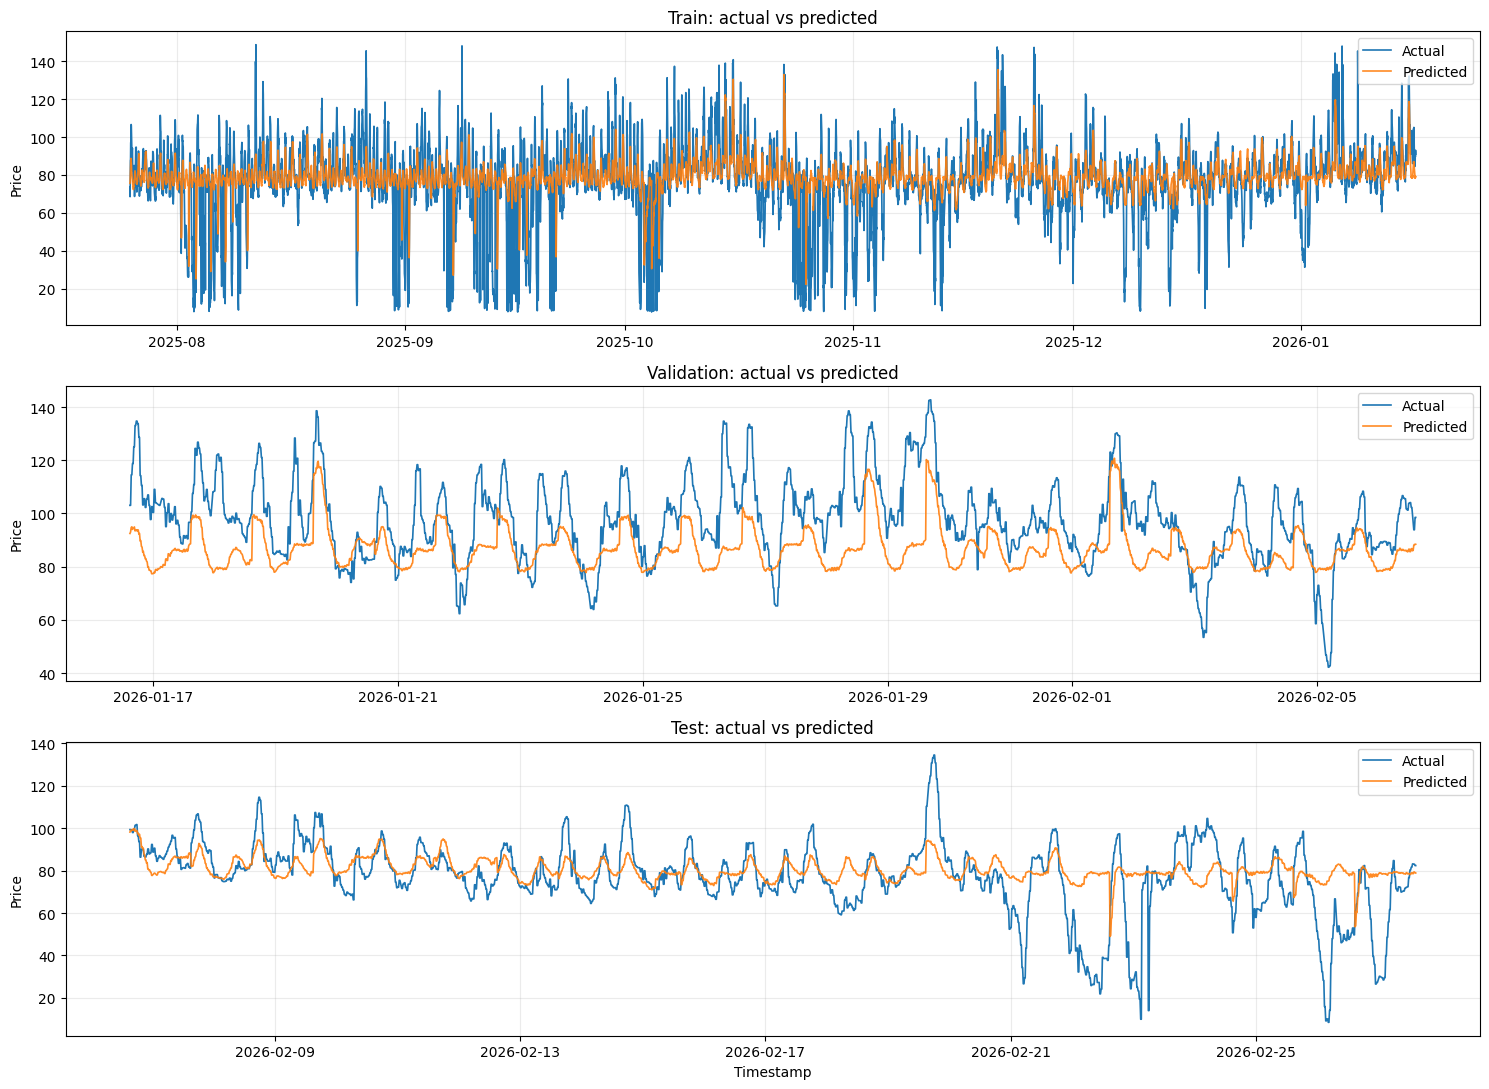

In [20]:
# Plot actual vs predicted for train/validation/test
import matplotlib.pyplot as plt


def build_split_plot_df(
    split_name: str,
    start_idx: int,
    true_windows: np.ndarray,
    pred_windows: np.ndarray,
) -> pd.DataFrame:
    if true_windows.size == 0 or pred_windows.size == 0:
        return pd.DataFrame(columns=["Split", "Timestamp", "Actual", "Predicted"])

    true_flat = true_windows.reshape(-1)
    pred_flat = pred_windows.reshape(-1)
    n = int(min(len(true_flat), len(pred_flat)))
    ts = df.iloc[start_idx : start_idx + n]["Timestamp"].to_numpy()

    return pd.DataFrame(
        {
            "Split": split_name,
            "Timestamp": ts,
            "Actual": true_flat[:n],
            "Predicted": pred_flat[:n],
        }
    )


train_plot_df = build_split_plot_df("Train", train_eval_start, train_true_w, train_pred_w)
val_plot_df = build_split_plot_df("Validation", val_start, val_true_w, val_pred_w)
test_plot_df = build_split_plot_df("Test", test_start, test_true_w, test_pred_w)

split_frames = [train_plot_df, val_plot_df, test_plot_df]

fig, axes = plt.subplots(3, 1, figsize=(15, 11), sharex=False)
for ax, split_df in zip(axes, split_frames):
    split_name = split_df["Split"].iloc[0] if not split_df.empty else "Unknown"
    if split_df.empty:
        ax.set_title(f"{split_name}: no windows available")
        ax.grid(alpha=0.25)
        continue

    # Downsample very long series so plotting remains responsive.
    step = max(1, len(split_df) // 8000)
    view = split_df.iloc[::step]

    ax.plot(view["Timestamp"], view["Actual"], label="Actual", linewidth=1.2, color="#1f77b4")
    ax.plot(view["Timestamp"], view["Predicted"], label="Predicted", linewidth=1.2, color="#ff7f0e", alpha=0.9)
    ax.set_title(f"{split_name}: actual vs predicted")
    ax.set_ylabel("Price")
    ax.grid(alpha=0.25)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

In [21]:
single_recursive.get_feature_importances()

,feature,importance
0,lag_1,6442
1,lag_2,3706
115,quarter_hour,3608
56,roll_std_4,2664
109,demand_inddem,2218
...,...,...
99,snowfall_sum,4
84,snowfall,1
118,is_weekend,0
119,is_holiday,0


In [22]:
# Build future exogenous features for next 24h (96 steps) using recent intraday profiles
def build_future_exog(history_df: pd.DataFrame, feature_columns: list[str], horizon: int = 96) -> tuple[pd.DatetimeIndex, pd.DataFrame]:
    last_ts = history_df["Timestamp"].max()
    future_ts = pd.date_range(last_ts + pd.Timedelta(minutes=15), periods=horizon, freq="15min")
    future = pd.DataFrame({"Timestamp": future_ts})

    uk_holidays_local = holidays.CountryHoliday("UK")
    future["hour"] = future["Timestamp"].dt.hour.astype(int)
    future["quarter_hour"] = (future["Timestamp"].dt.minute // 15).astype(int)
    future["quarter_of_day"] = ((future["Timestamp"].dt.hour * 60 + future["Timestamp"].dt.minute) // 15).astype(int)
    future["day_of_week"] = future["Timestamp"].dt.dayofweek.astype(int)
    future["is_weekend"] = (future["Timestamp"].dt.dayofweek >= 5).astype(int)
    future["is_holiday"] = future["Timestamp"].dt.date.isin(uk_holidays_local).astype(int)
    future["is_working_day"] = ((future["is_weekend"] == 0) & (future["is_holiday"] == 0)).astype(int)

    minute_of_day_future = future["Timestamp"].dt.hour * 60 + future["Timestamp"].dt.minute
    future["tod_sin"] = np.sin(2 * np.pi * minute_of_day_future / 1440.0)
    future["tod_cos"] = np.cos(2 * np.pi * minute_of_day_future / 1440.0)
    future["dow_sin"] = np.sin(2 * np.pi * future["Timestamp"].dt.dayofweek / 7.0)
    future["dow_cos"] = np.cos(2 * np.pi * future["Timestamp"].dt.dayofweek / 7.0)
    future["is_price_patched"] = 0.0

    recent = history_df[history_df["Timestamp"] >= (history_df["Timestamp"].max() - pd.Timedelta(days=56))].copy()
    if recent.empty:
        recent = history_df.copy()

    if "quarter_of_day" not in recent.columns:
        recent["quarter_of_day"] = ((recent["Timestamp"].dt.hour * 60 + recent["Timestamp"].dt.minute) // 15).astype(int)
    if "day_of_week" not in recent.columns:
        recent["day_of_week"] = recent["Timestamp"].dt.dayofweek.astype(int)

    generated = {
        "hour",
        "quarter_hour",
        "quarter_of_day",
        "day_of_week",
        "is_weekend",
        "is_holiday",
        "is_working_day",
        "tod_sin",
        "tod_cos",
        "dow_sin",
        "dow_cos",
        "is_price_patched",
    }

    for col in feature_columns:
        if col in generated:
            continue
        if col not in recent.columns or not pd.api.types.is_numeric_dtype(recent[col]):
            future[col] = 0.0
            continue

        by_dow_qod = recent.groupby(["day_of_week", "quarter_of_day"])[col].median()
        by_qod = recent.groupby("quarter_of_day")[col].median()
        fallback = float(recent[col].median())

        dow_qod_idx = pd.MultiIndex.from_frame(future[["day_of_week", "quarter_of_day"]])
        mapped_dow_qod = pd.Series(dow_qod_idx.map(by_dow_qod), index=future.index, dtype=float)
        mapped_qod = future["quarter_of_day"].map(by_qod).astype(float)

        future[col] = mapped_dow_qod.fillna(mapped_qod).fillna(fallback)

    future_exog = future[feature_columns].copy()
    for col in future_exog.columns:
        future_exog[col] = pd.to_numeric(future_exog[col], errors="coerce").ffill().bfill().fillna(0.0)
    return future_ts, future_exog

future_ts, future_exog = build_future_exog(df, feature_cols, horizon=HORIZON)
display(future_exog.head(3))

,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,rain,snowfall,cloud_cover,cloud_cover_low,cloud_cover_mid,cloud_cover_high,...,wind_generation,solar_generation,margin_daily_forecast,hour,quarter_hour,quarter_of_day,day_of_week,is_weekend,is_holiday,is_working_day
0,3.25,90.53535,1.85,0.0,0.0,0.0,100.0,100.0,89.0,100.0,...,13534.097,836.0,12310.0,15,0,60,4,0,0,1
1,3.25,90.53535,1.85,0.0,0.0,0.0,100.0,100.0,89.0,100.0,...,13534.097,836.0,12310.0,15,1,61,4,0,0,1
2,3.25,90.53535,1.85,0.0,0.0,0.0,100.0,100.0,89.0,100.0,...,13436.854,334.5,12310.0,15,2,62,4,0,0,1


In [23]:
# Forecast next 24 hours (96 x 15min) using the already-trained single model
if "single_recursive" not in globals():
    raise RuntimeError("Run cell 9 first to train the single model before forecasting.")

if "y_all" not in globals():
    raise RuntimeError("Run cell 9 first so y_all is available.")

future_exog_for_pred = future_exog.copy()
future_exog_for_pred.index = pd.RangeIndex(start=len(y_all), stop=len(y_all) + HORIZON, step=1)
last_window_for_future = y_all.iloc[-MAX_LAG:]

next_96_pred = single_recursive.predict(
    steps=HORIZON,
    last_window=last_window_for_future,
    exog=future_exog_for_pred,
)

forecast_df = pd.DataFrame({
    "Timestamp": future_ts,
    "predicted_price": next_96_pred.values,
})

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
forecast_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")

display(forecast_df.head())

Saved: c:\Users\rkale\OneDrive\Documentos\VStudio\GitHub\Gitlab\25-26_CE903-SP_team03\Prediction\lgbm_skforecast_direct_day_ahead_24h_15min.csv


,Timestamp,predicted_price
0,2026-02-27 15:00:00,84.620243
1,2026-02-27 15:15:00,84.614769
2,2026-02-27 15:30:00,85.213257
3,2026-02-27 15:45:00,85.063299
4,2026-02-27 16:00:00,85.740888


## Production note
For true day-ahead use, replace the projected exogenous values with forecast weather/demand values for the next 96 time steps.